# Nuova nuova versione dell'interfaccia

In [45]:
from serial.tools import list_ports
import sys
import os
from src.lib.new_drivers import Bilancia, Camera
from matplotlib import pyplot as plt
import matplotlib.patches as pa
import ipywidgets as widgets
from collections import deque
import ipywidgets as widgets
from matplotlib import pyplot as plt
import os
import time
import numpy as np

In [46]:
%matplotlib widget
plt.close('all')

In [47]:
class BaseInterface:
    def __init__(self):
        self.fig = None
        self.axes = None
        self.update_timer = None
        self.widgets = {}

        self.output = widgets.Output()
    
    def _init_plot(self, suptitle, ncols, nrows, plot_types, plot_titles=None, xlabels=None, ylabels=None):
        with plt.ioff():

            self.fig, self.axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(6*ncols, 6*nrows))
            
            self.fig.suptitle(suptitle)
            
            if ncols == 1 and nrows == 1:
                self.axes = np.array([[self.axes]])
            elif ncols == 1:
                self.axes = self.axes[:, np.newaxis]
            elif nrows == 1:
                self.axes = self.axes[np.newaxis, :]
            
            for i in range(nrows):
                for j in range(ncols):
                    plot_type = plot_types[i][j]
                    if plot_type == 'image':
                        self.axes[i, j].imshow(np.zeros((10, 10)), cmap='gray')
                    elif plot_type == 'line':
                        self.axes[i, j].plot([], [])
                    elif plot_type == 'scatter':
                        self.axes[i, j].scatter([], [])
                    
                    if plot_titles is not None:
                        self.axes[i, j].set_title(plot_titles[i][j])
                    if xlabels is not None and ylabels is not None:
                        self.axes[i, j].set_xlabel(xlabels[i][j])
                        self.axes[i, j].set_ylabel(ylabels[i][j])

    def _start_update_plot(self, interval=100):
        self.update_timer = self.fig.canvas.new_timer(interval=interval)
        self.update_timer.add_callback(self._update_plot)
        self.update_timer.start()
    
    def _stop_update_plot(self):
        if self.update_timer is not None:
            self.update_timer.stop()
            self.update_timer = None
        
    def _set_lims(self, lims, plot_types):
        for i in range(len(self.axes)):
            for j in range(len(self.axes[i])):

                if plot_types[i][j] is None:
                    continue
                
                if plot_types[i][j] == 'image':
                    self.axes[i, j].set_clim(*lims[i][j])

                if plot_types[i][j] in ['line', 'scatter']:
                    self.axes[i, j].set_xlim(lims[i][j][0])
                    self.axes[i, j].set_ylim(lims[i][j][1])
    
    def _set_lim(self, lim, plot_type, i, j):
        if plot_type is None:
            return
        
        if plot_type == 'image':
            self.axes[i, j].set_clim(*lim)

        if plot_type in ['line', 'scatter']:
            self.axes[i, j].set_xlim(lim[0])
            self.axes[i, j].set_ylim(lim[1])
    
    def _update_plot(self):
        pass
            


In [48]:
class CameraInterface(BaseInterface):
    def __init__(self, camera_index=0):
        super().__init__()

        self.frames = []
        self.reference_image = None

        self.roi_center = None
        self.roi_radius = None

        self.camera = None

        self.camera_index = camera_index

        self.widgets["start_btn"] = widgets.Button(description="Start Camera")
        self.widgets["stop_btn"] = widgets.Button(description="Stop Camera")

        self._init_plot(
            suptitle="Camera Interface",
            ncols=2,
            nrows=2,
            plot_types=[['image', "image"], ["image", "image"]],
            plot_titles=[['Live camera', 'Differences'], ['Roi selection', 'Roi differences']],
        )

        self.widgets["start_btn"].on_click(lambda _: self.on_start_btn())
        self.widgets["stop_btn"].on_click(lambda _: self.on_stop_btn())

        self.fig.canvas.mpl_connect('button_press_event', self.on_roi_click)

        self.show()


    def show(self):
        display(self.output)
        display(widgets.HBox([self.widgets["start_btn"], self.widgets["stop_btn"]]))
        display(self.fig.canvas)
    
    def connect_camera(self):
        try:
            self.camera = Camera(self.camera_index, keep_frames=1)
            if self.camera.cap.isOpened():
                with self.output:
                    print("Camera connessa con successo!")
            else:
                with self.output:
                    print("Impossibile aprire la camera.")
                raise Exception("Camera non aperta")
        
        except Exception as e:
            with self.output:
                print(f"Errore durante la connessione alla camera: {e}")
            
            self.camera = None
            return
        
    def on_start_btn(self):
        with self.output:
            print("Starting camera...")
            
        self.connect_camera()
        self.camera._acquire_reference_image()
        self.reference_image = self.camera.im0
        self.camera.start_acquisition(center_x=320, center_y=240, radius=100, interval=0.1)

        self._start_update_plot(interval=100)


        # forse meglio annche svuotare i frame

    def on_stop_btn(self):
        if self.camera is not None:
            self.camera.stop_acquisition()
            self.camera.release()
            self.camera = None
            with self.output:
                print("Camera stopped.")
        else:
            with self.output:
                print("No camera to stop.")
        
        if self.update_timer is not None:
            self._stop_update_plot()
    
    def on_roi_click(self, event):
        if event.inaxes == self.axes[1, 0]:
            self.roi_center = (int(event.xdata), int(event.ydata))
            self.roi_radius = 50  # Puoi rendere questo dinamico se vuoi

            with self.output:
                print(f"ROI center set to: {self.roi_center}")
            
            self.camera.update_roi(self.roi_center[0], self.roi_center[1], self.roi_radius)

    def _update_plot(self):

        if self.camera is None:
            return
    
        sample = self.camera.get_latest_image()

        data, ts = sample

        frame = data[0]
        roi = data[1]

        self.camera.images.clear()  # Pulisce il buffer delle immagini dopo aver preso l'ultima
        self.camera.timestamps.clear()  # Pulisce il buffer dei timestamp

        if frame is not None:
            # il primo plot è l'immagine in tempo reale
            self.axes[0, 0].imshow(frame, cmap='gray')

            self.frames.append(frame)

            if len(self.frames) > 10:
                self.frames.pop(0)

            # il secondo plot è la differenza tra l'immagine corrente e la media delle ultime 10 immagini
            avg_frame = np.mean(self.frames, axis=0)
            diff = np.abs(frame - avg_frame)
            self.axes[0, 1].imshow(diff, cmap='gray')


            # il terzo è la selezione della roi
            pass

            # il quarto è la differenza ritagliata secondo la roi
            roi_mask = self.camera.masks["total"]
            roi_diff = diff * roi_mask
            self.axes[1, 1].imshow(roi_diff, cmap='gray')

            if self.roi_center is not None and self.roi_radius is not None:
                self.axes[1, 1].set_xlim(self.roi_center[0] - self.roi_radius, self.roi_center[0] + self.roi_radius)
                self.axes[1, 1].set_ylim(self.roi_center[1] - self.roi_radius, self.roi_center[1] + self.roi_radius)



        self.fig.canvas.draw_idle()
        



Output()

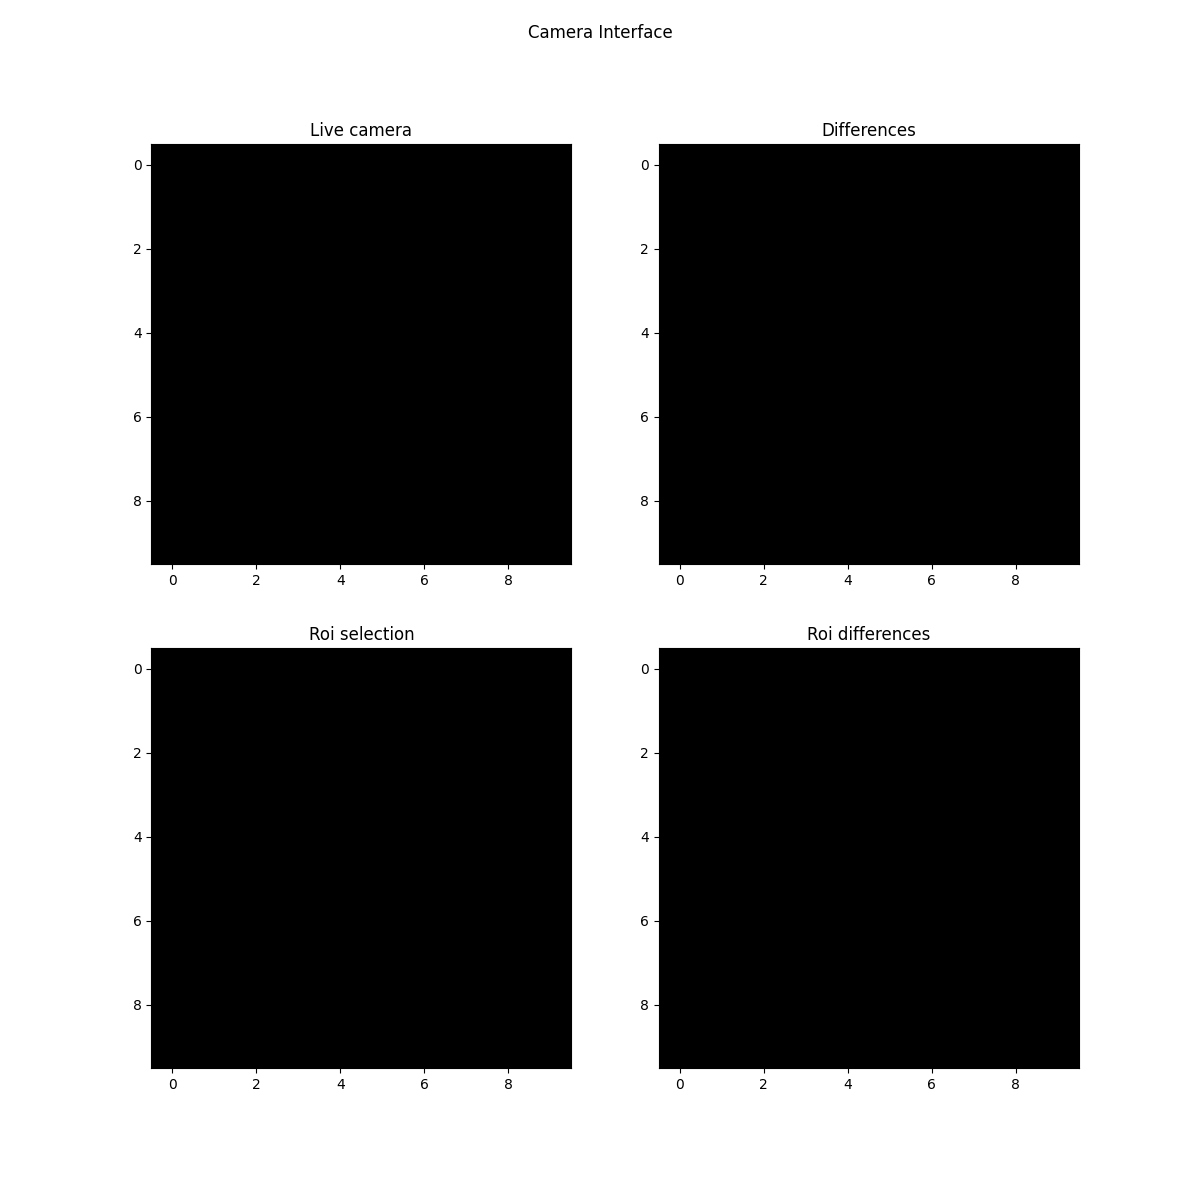

In [49]:
camera = CameraInterface()